In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import os
import numpy as np# Thi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
path = kagglehub.dataset_download("salmansajid05/oral-diseases")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/salmansajid05/oral-diseases


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/kaggle/input/oral-diseases"
NUM_CLASSES = None

In [7]:
path_obj = Path(path)
for folder in sorted(path_obj.rglob("*")):
    if folder.is_dir():
        level = len(folder.relative_to(path_obj).parts)
        indent = "    " * level
        print(f"{indent}{folder.name}")

    Calculus
        Calculus
    Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
        Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
            Data
                images
                    train
                    val
                labels
                    train
                    val
    Data caries
        Data caries
            caries augmented data set
                preview
            caries orignal data set
                done
    Gingivitis
        Gingivitis
    Mouth Ulcer
        Mouth Ulcer
            Mouth_Ulcer_augmented_DataSet
                preview
            ulcer original dataset
                ulcer original dataset
    Tooth Discoloration
        Tooth Discoloration 
            Tooth_discoloration_augmented_dataser
                preview
            tooth discoloration original dataset
                tooth discoloration original dataset
    hypodontia
        hypodontia


In [8]:
data_path = Path(path)

class_folders = {
    "Calculus": [
        "Calculus/Calculus"
    ],
    "Caries": [
        "Data caries/Data caries/caries augmented data set",
        "Data caries/Data caries/caries orignal data set/done"
    ],
    "Gingivitis": [
        "Gingivitis/Gingivitis"
    ],
    "Mouth_Ulcer": [
        "Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet",
        "Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset"
    ],
    "Tooth_Discoloration": [
        "Tooth Discoloration/Tooth Discoloration/Tooth_discoloration_augmented_dataser",
        "Tooth Discoloration/Tooth Discoloration/tooth discoloration original dataset/tooth discoloration original dataset"
    ],
    "Hypodontia": [
        "hypodontia/hypodontia"
    ],
}

In [10]:
original_dirs = {
    'Calculus': '/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus',
    'Caries': '/kaggle/input/datasets/salmansajid05/oral-diseases/Data caries/Data caries/caries augmented data set/preview',
    'Gingivitis': '/kaggle/input/datasets/salmansajid05/oral-diseases/Gingivitis/Gingivitis',
    'Ulcers': '/kaggle/input/datasets/salmansajid05/oral-diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview',
    'Tooth Discoloration': '/kaggle/input/datasets/salmansajid05/oral-diseases/Tooth Discoloration/Tooth Discoloration /Tooth_discoloration_augmented_dataser/preview',
    'Hypodontia': '/kaggle/input/datasets/salmansajid05/oral-diseases/hypodontia/hypodontia'
}
for class_name,path in original_dirs.items():
    print(f'Class Name --> {class_name} and total number of images {len(os.listdir(path))}')
    print()

Class Name --> Calculus and total number of images 1296

Class Name --> Caries and total number of images 2382

Class Name --> Gingivitis and total number of images 2349

Class Name --> Ulcers and total number of images 2541

Class Name --> Tooth Discoloration and total number of images 1834

Class Name --> Hypodontia and total number of images 1251



                 class  count
0             Calculus   1296
1               Caries   2382
2           Gingivitis   2349
3               Ulcers   2541
4  Tooth Discoloration   1834
5           Hypodontia   1251
Total images: 11653


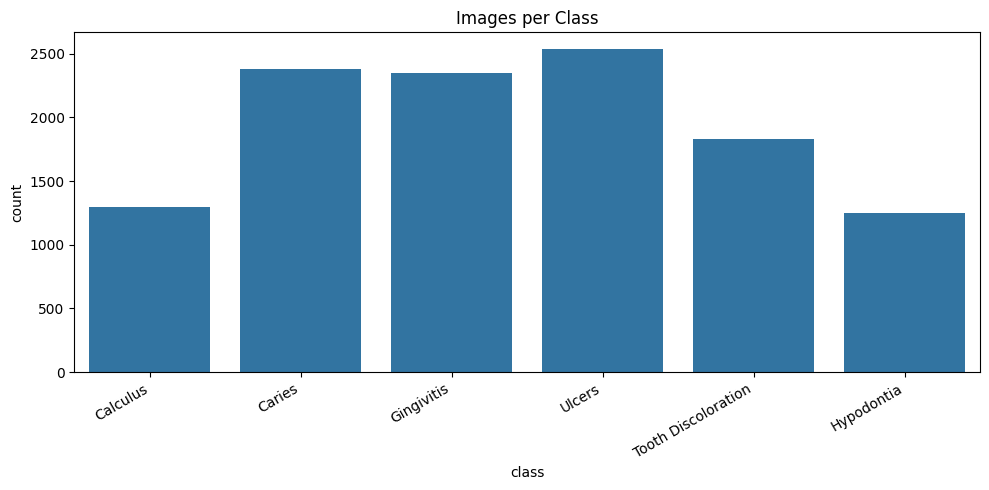

In [11]:
classes = list(original_dirs.keys())
NUM_CLASSES = len(classes)

counts_df = pd.DataFrame(
    [(c, len(os.listdir(p))) for c, p in original_dirs.items()],
    columns=["class", "count"]
)
print(counts_df)
print("Total images:", counts_df["count"].sum())

plt.figure(figsize=(10, 5))
sns.barplot(data=counts_df, x="class", y="count")
plt.xticks(rotation=30, ha="right")
plt.title("Images per Class")
plt.tight_layout()
plt.show()

In [12]:
img_exts = (".jpg", ".jpeg", ".png", ".bmp")

records = []
for cls, folder in original_dirs.items():
    for fname in os.listdir(folder):
        if fname.lower().endswith(img_exts):
            records.append({
                "filepath": os.path.join(folder, fname),
                "label": cls
            })

oral = pd.DataFrame(records)
print(oral.shape)
print(oral["label"].value_counts())
oral.head()

(11653, 2)
label
Ulcers                 2541
Caries                 2382
Gingivitis             2349
Tooth Discoloration    1834
Calculus               1296
Hypodontia             1251
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
1,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
2,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
3,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
4,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus


In [13]:
train_oral, temp_oral = train_test_split(
    oral,
    test_size=0.3,
    stratify=oral["label"],
    random_state=SEED
)

val_oral, test_oral = train_test_split(
    temp_oral,
    test_size=0.5,
    stratify=temp_oral["label"],
    random_state=SEED
)

print("Train:", train_oral.shape)
print("Val:  ", val_oral.shape)
print("Test: ", test_oral.shape)

print("\nTrain distribution:\n", train_oral["label"].value_counts())
print("\nVal distribution:\n", val_oral["label"].value_counts())
print("\nTest distribution:\n", test_oral["label"].value_counts())

Train: (8157, 2)
Val:   (1748, 2)
Test:  (1748, 2)

Train distribution:
 label
Ulcers                 1779
Caries                 1667
Gingivitis             1644
Tooth Discoloration    1284
Calculus                907
Hypodontia              876
Name: count, dtype: int64

Val distribution:
 label
Ulcers                 381
Caries                 358
Gingivitis             352
Tooth Discoloration    275
Calculus               194
Hypodontia             188
Name: count, dtype: int64

Test distribution:
 label
Ulcers                 381
Caries                 357
Gingivitis             353
Tooth Discoloration    275
Calculus               195
Hypodontia             187
Name: count, dtype: int64


In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_oral,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_oral,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_oral,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 8157 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.
Class indices: {'Calculus': 0, 'Caries': 1, 'Gingivitis': 2, 'Hypodontia': 3, 'Tooth Discoloration': 4, 'Ulcers': 5}


In [15]:
print(NUM_CLASSES)

6


In [16]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

I0000 00:00:1783894435.456511      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783894435.459813      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_cnn = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
  2/255 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.1875 - loss: 2.1669 

I0000 00:00:1783894463.413563     176 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


255/255 ━━━━━━━━━━━━━━━━━━━━ 175s 640ms/step - accuracy: 0.4790 - loss: 1.2962 - val_accuracy: 0.2048 - val_loss: 4.7975 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 113s 444ms/step - accuracy: 0.5919 - loss: 1.0184 - val_accuracy: 0.2717 - val_loss: 2.7771 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 117s 458ms/step - accuracy: 0.6419 - loss: 0.8938 - val_accuracy: 0.5641 - val_loss: 1.1032 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 116s 456ms/step - accuracy: 0.6855 - loss: 0.7908 - val_accuracy: 0.5961 - val_loss: 1.0274 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 112s 440ms/step - accuracy: 0.7093 - loss: 0.7311 - val_accuracy: 0.6098 - val_loss: 1.0274 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 112s 440ms/step - accuracy: 0.7375 - loss: 0.6571 - val_accuracy: 0.6922 - val_loss: 0.7991 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 112s 439ms/step - accuracy: 0.7580 

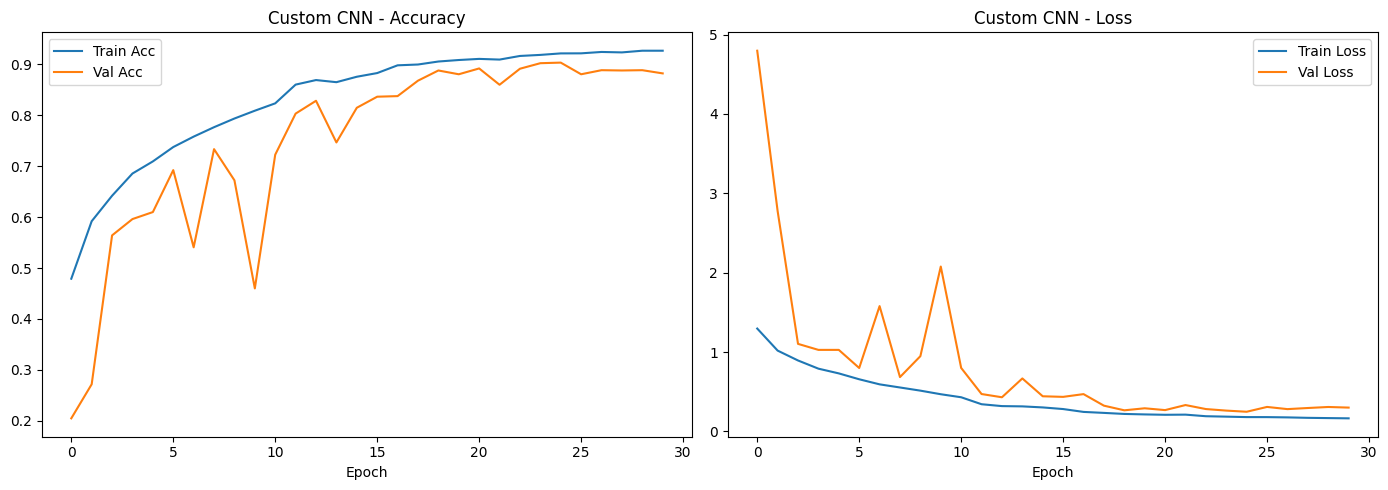

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.9022 - loss: 0.2394
Custom CNN Test Accuracy: 0.9022
Custom CNN Test Loss: 0.2394


In [20]:
def plot_history(history, title="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Custom CNN")

test_loss, test_acc = custom_cnn.evaluate(test_generator)
print(f"Custom CNN Test Accuracy: {test_acc:.4f}")
print(f"Custom CNN Test Loss: {test_loss:.4f}")

In [23]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
resnet_eval_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

resnet_train_gen = resnet_train_datagen.flow_from_dataframe(
    train_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED
)
resnet_val_gen = resnet_eval_datagen.flow_from_dataframe(
    val_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
resnet_test_gen = resnet_eval_datagen.flow_from_dataframe(
    test_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

def build_pretrained_model(base_model_class, input_shape=(224, 224, 3), num_classes=NUM_CLASSES, base_name="base"):
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=base_name)
    return model, base_model

resnet_model, resnet_base = build_pretrained_model(ResNet50, base_name="ResNet50_model")
resnet_model.summary()

Found 8157 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.


Model: "ResNet50_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_r = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_r = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_resnet = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=20,
    callbacks=[early_stop_r, reduce_lr_r]
)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 133s 483ms/step - accuracy: 0.6679 - loss: 0.8498 - val_accuracy: 0.7878 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 115s 451ms/step - accuracy: 0.7732 - loss: 0.5691 - val_accuracy: 0.7981 - val_loss: 0.4660 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 117s 458ms/step - accuracy: 0.7939 - loss: 0.5031 - val_accuracy: 0.8392 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 116s 453ms/step - accuracy: 0.8113 - loss: 0.4526 - val_accuracy: 0.8289 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 116s 455ms/step - accuracy: 0.8260 - loss: 0.4169 - val_accuracy: 0.8621 - val_loss: 0.3099 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 117s 457ms/step - accuracy: 0.8311 - loss: 0.4061 - val_accuracy: 0.8633 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 116s 455ms/step - accura

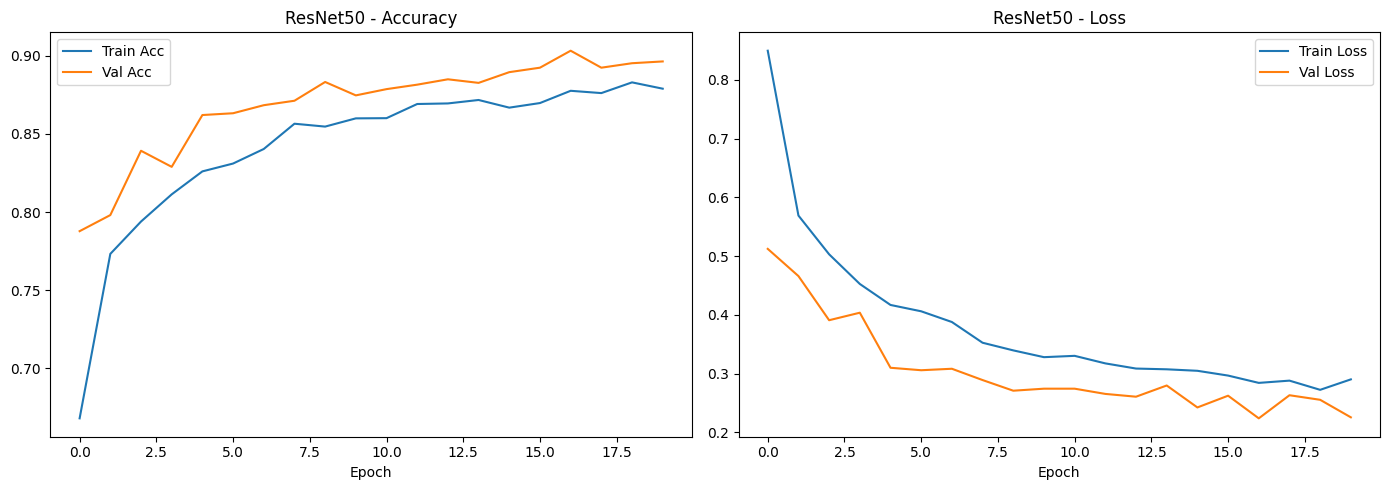

55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.9016 - loss: 0.2308
ResNet50 Test Accuracy: 0.9016
ResNet50 Test Loss: 0.2308


In [25]:
plot_history(history_resnet, "ResNet50")

test_loss_r, test_acc_r = resnet_model.evaluate(resnet_test_gen)
print(f"ResNet50 Test Accuracy: {test_acc_r:.4f}")
print(f"ResNet50 Test Loss: {test_loss_r:.4f}")

In [26]:
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

eff_train_datagen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
eff_eval_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    train_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED
)
eff_val_gen = eff_eval_datagen.flow_from_dataframe(
    val_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
eff_test_gen = eff_eval_datagen.flow_from_dataframe(
    test_oral, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

effnet_model, effnet_base = build_pretrained_model(EfficientNetB0, base_name="EfficientNetB0_model")
effnet_model.summary()

Found 8157 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.
Found 1748 validated image filenames belonging to 6 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [27]:
effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_e = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_e = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_effnet = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=20,
    callbacks=[early_stop_e, reduce_lr_e]
)

Epoch 1/20


2026-07-13 00:30:38.957648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:30:39.102382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:30:39.453199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:30:39.595433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:30:39.736445: E external/local_xla/xla/stream_

 74/255 ━━━━━━━━━━━━━━━━━━━━ 1:15 416ms/step - accuracy: 0.5129 - loss: 1.2875

2026-07-13 00:31:25.619170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:31:25.762091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:31:26.107383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:31:26.248195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:31:27.024404: E external/local_xla/xla/stream_

255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.6242 - loss: 0.9770

2026-07-13 00:33:04.181695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:33:04.322112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:33:04.656278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:33:04.797350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 00:33:05.572345: E external/local_xla/xla/stream_

255/255 ━━━━━━━━━━━━━━━━━━━━ 169s 558ms/step - accuracy: 0.7030 - loss: 0.7594 - val_accuracy: 0.7941 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 433ms/step - accuracy: 0.8050 - loss: 0.4808 - val_accuracy: 0.8232 - val_loss: 0.4348 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 114s 447ms/step - accuracy: 0.8280 - loss: 0.4207 - val_accuracy: 0.8507 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 435ms/step - accuracy: 0.8524 - loss: 0.3736 - val_accuracy: 0.8644 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 433ms/step - accuracy: 0.8589 - loss: 0.3417 - val_accuracy: 0.8576 - val_loss: 0.3169 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 110s 433ms/step - accuracy: 0.8701 - loss: 0.3222 - val_accuracy: 0.8558 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 110s 432ms/step - accuracy: 0.8746 

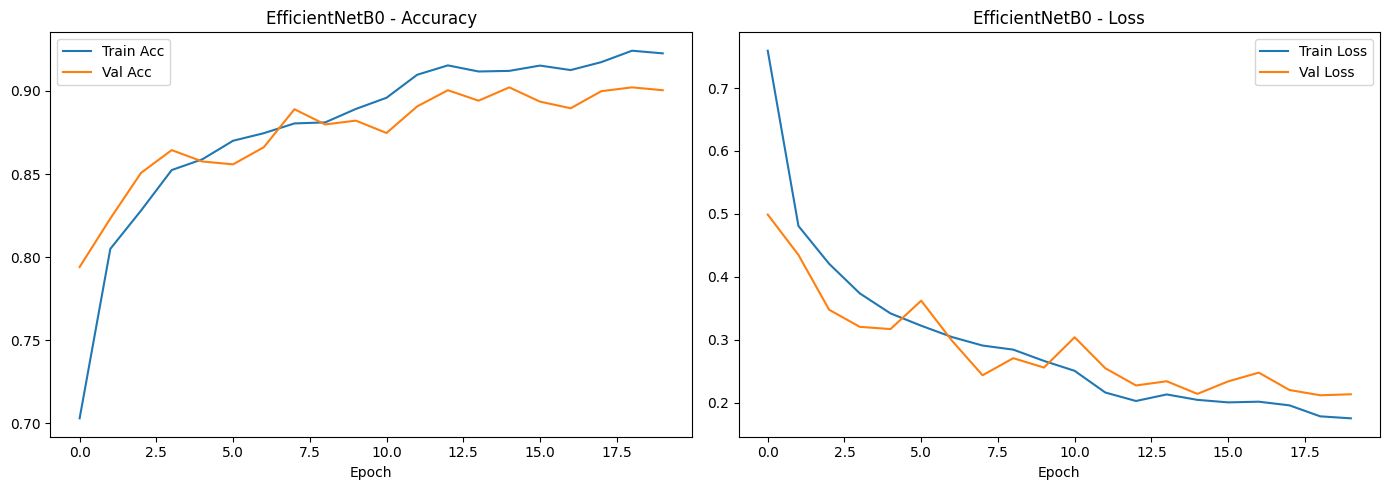

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.9119 - loss: 0.1954
EfficientNetB0 Test Accuracy: 0.9119
EfficientNetB0 Test Loss: 0.1954


In [28]:
plot_history(history_effnet, "EfficientNetB0")

test_loss_e, test_acc_e = effnet_model.evaluate(eff_test_gen)
print(f"EfficientNetB0 Test Accuracy: {test_acc_e:.4f}")
print(f"EfficientNetB0 Test Loss: {test_loss_e:.4f}")

In [29]:
effnet_base.trainable = True

fine_tune_at = len(effnet_base.layers) - 30
for layer in effnet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in base: {len(effnet_base.layers)}")
print(f"Trainable layers: {len(effnet_base.layers) - fine_tune_at}")

effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

history_effnet_ft = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[early_stop_ft, reduce_lr_ft]
)

Total layers in base: 238
Trainable layers: 30
Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 165s 541ms/step - accuracy: 0.7640 - loss: 0.7298 - val_accuracy: 0.8541 - val_loss: 0.3752 - learning_rate: 1.0000e-05
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 112s 439ms/step - accuracy: 0.8189 - loss: 0.5078 - val_accuracy: 0.8598 - val_loss: 0.3671 - learning_rate: 1.0000e-05
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 112s 437ms/step - accuracy: 0.8352 - loss: 0.4471 - val_accuracy: 0.8696 - val_loss: 0.3327 - learning_rate: 1.0000e-05
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 436ms/step - accuracy: 0.8517 - loss: 0.4016 - val_accuracy: 0.8810 - val_loss: 0.3017 - learning_rate: 1.0000e-05
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 433ms/step - accuracy: 0.8620 - loss: 0.3648 - val_accuracy: 0.8867 - val_loss: 0.2871 - learning_rate: 1.0000e-05
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 111s 437ms/step - accuracy: 0.8665 - loss: 0.3427 - val_accuracy: 0.8896 - val_loss: 0.2763 - learning_rate: 1.00

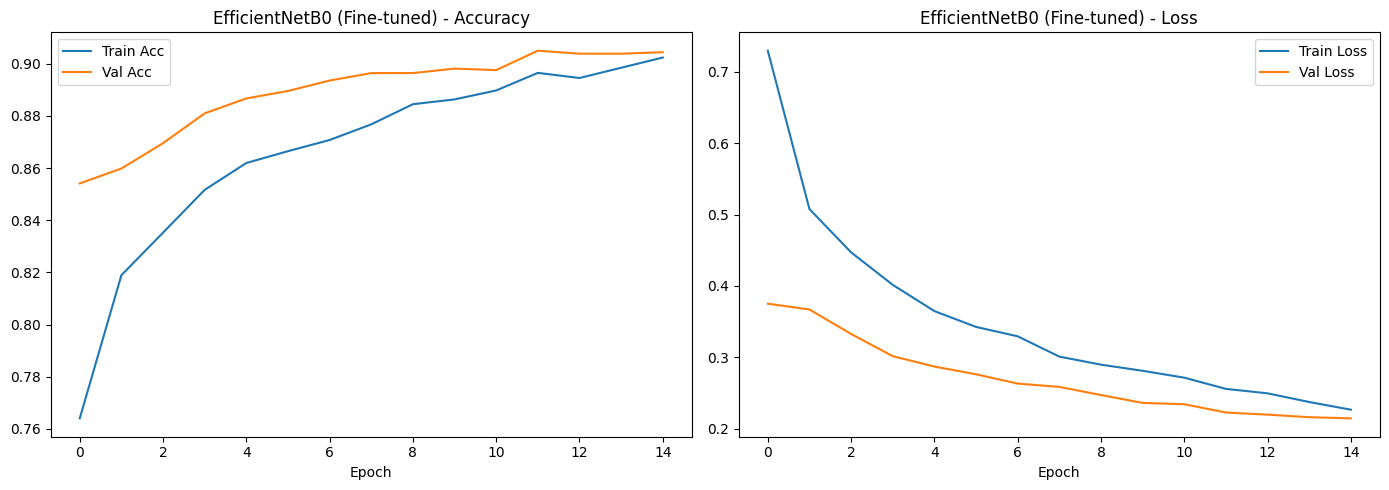

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9130 - loss: 0.2136 
EfficientNetB0 (Fine-tuned) Test Accuracy: 0.9130
EfficientNetB0 (Fine-tuned) Test Loss: 0.2136


In [30]:
plot_history(history_effnet_ft, "EfficientNetB0 (Fine-tuned)")

test_loss_ft, test_acc_ft = effnet_model.evaluate(eff_test_gen)
print(f"EfficientNetB0 (Fine-tuned) Test Accuracy: {test_acc_ft:.4f}")
print(f"EfficientNetB0 (Fine-tuned) Test Loss: {test_loss_ft:.4f}")

                         Model  Test Accuracy  Test Loss  \
0                   Custom CNN       0.902200   0.239400   
1                     ResNet50       0.901600   0.230800   
2      EfficientNetB0 (frozen)       0.911900   0.195400   
3  EfficientNetB0 (fine-tuned)       0.913043   0.213609   

    Trainable Params (approx)  
0                 457K (full)  
1            526K (head only)  
2            526K (head only)  
3  ~4M (head + top 30 layers)  


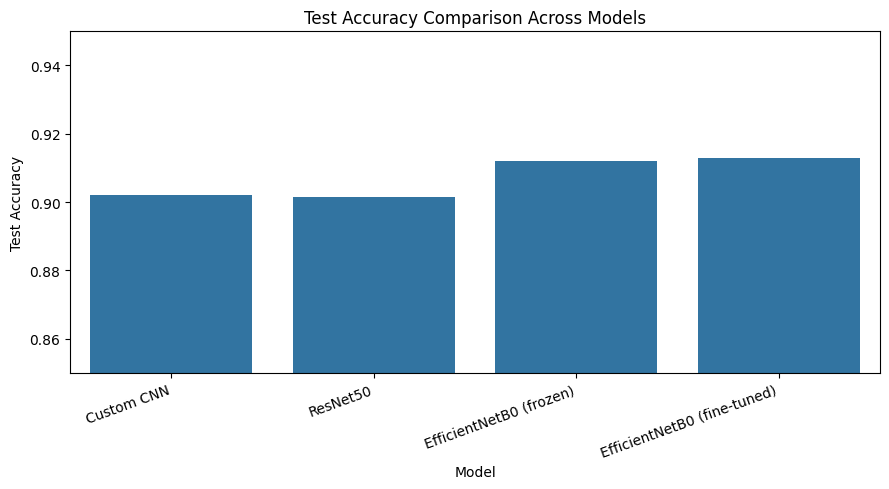

In [31]:
comparison = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet50", "EfficientNetB0 (frozen)", "EfficientNetB0 (fine-tuned)"],
    "Test Accuracy": [0.9022, 0.9016, 0.9119, test_acc_ft],
    "Test Loss": [0.2394, 0.2308, 0.1954, test_loss_ft],
    "Trainable Params (approx)": ["457K (full)", "526K (head only)", "526K (head only)", "~4M (head + top 30 layers)"]
})
print(comparison)

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="Model", y="Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.85, 0.95)
plt.title("Test Accuracy Comparison Across Models")
plt.tight_layout()
plt.show()

In [32]:
effnet_model.save("best_model_efficientnetb0_finetuned.keras")
print("Model saved successfully.")

Model saved successfully.


In [33]:
import json
class_indices = train_generator.class_indices  # {'Calculus': 0, 'Caries': 1, ...}
idx_to_class = {v: k for k, v in class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f)
print(idx_to_class)

{0: 'Calculus', 1: 'Caries', 2: 'Gingivitis', 3: 'Hypodontia', 4: 'Tooth Discoloration', 5: 'Ulcers'}


In [34]:
!pip install -q gradio

import gradio as gr
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from PIL import Image

In [42]:
model = tf.keras.models.load_model("best_model_efficientnetb0_finetuned.keras")

with open("class_indices.json", "r") as f:
    idx_to_class = json.load(f)
    idx_to_class = {int(k): v for k, v in idx_to_class.items()}

def predict_oral_disease(img):
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = eff_preprocess(img_array)

    preds = model.predict(img_array)[0]
    confidences = {idx_to_class[i]: float(preds[i]) for i in range(len(preds))}
    return confidences

In [48]:
import json

import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

MODEL_PATH = "best_model_efficientnetb0_finetuned.keras"
CLASS_INDICES_PATH = "class_indices.json"

model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_INDICES_PATH, "r") as f:
    idx_to_class = json.load(f)
    idx_to_class = {int(k): v for k, v in idx_to_class.items()}

def predict_oral_disease(img):
    if img is None:
        return None

    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = eff_preprocess(img_array)

    preds = model.predict(img_array)[0]
    return {idx_to_class[i]: float(preds[i]) for i in range(len(preds))}

custom_css = """
.gradio-container {
    font-family: 'Segoe UI', sans-serif;
    max-width: 1000px !important;
    margin: auto !important;
}
#header {
    text-align: center;
    padding: 30px 20px;
    background: linear-gradient(135deg, #0f766e, #0369a1);
    border-radius: 16px;
    color: white;
    margin-bottom: 20px;
}
#header h1 {
    font-size: 32px;
    margin-bottom: 8px;
}
#header p {
    font-size: 15px;
    opacity: 0.9;
}
.class-card {
    text-align: center;
    padding: 10px;
    border-radius: 10px;
    background: #1e293b;
    font-size: 13px;
}
footer {visibility: hidden}
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="teal", secondary_hue="cyan"), css=custom_css) as demo:

    gr.HTML(
        """
        <div id="header">
            <h1>🦷 Oral Disease Classifier</h1>
            <p>AI-powered detection of oral health conditions from images — powered by EfficientNetB0</p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Upload an Image")
            image_input = gr.Image(type="pil", label="", height=300)
            predict_btn = gr.Button("Analyze Image", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### Results")
            output_label = gr.Label(num_top_classes=6, label="")

    gr.Markdown("### 🩺 Detectable Conditions")
    with gr.Row():
        for cls in ["Calculus", "Caries", "Gingivitis", "Hypodontia", "Tooth Discoloration", "Ulcers"]:
            gr.Markdown(f"**{cls}**", elem_classes="class-card")

    gr.Markdown(
        "---\n"
        "**Model:** EfficientNetB0 (fine-tuned)  |  **Test Accuracy:** 91.30%  |  "
        "Built with TensorFlow & Gradio\n\n"
        "*For educational purposes only — not a substitute for professional dental diagnosis.*"
    )

    predict_btn.click(fn=predict_oral_disease, inputs=image_input, outputs=output_label)
    image_input.change(fn=predict_oral_disease, inputs=image_input, outputs=output_label)


if __name__ == "__main__":
    demo.launch()

/tmp/ipykernel_58/1173881756.py:61: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="teal", secondary_hue="cyan"), css=custom_css) as demo:
/tmp/ipykernel_58/1173881756.py:61: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="teal", secondary_hue="cyan"), css=custom_css) as demo:


* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://914fc0e1fa532e6624.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [38]:
print(os.path.exists("best_model_efficientnetb0_finetuned.keras"))
print(os.path.exists("class_indices.json"))

True
True
